In [1]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import evaluate
import EIDA


model_name = "roberta-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)


max_length = 72
batch_size = 16
dataset = load_dataset("glue", "sst2")
def preprocess_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
tokenized_dataset = dataset.map(preprocess_function, batched=True)

train_dataset = tokenized_dataset['train']
dev_dataset = tokenized_dataset['validation']


metric = evaluate.load("glue", "sst2")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=1)
    return metric.compute(predictions=predictions, references=labels)

c:\Users\3un8i\anaconda3\envs\IDA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
train_dataset = train_dataset.shuffle()

input_ids = torch.tensor(train_dataset['input_ids'])
attention_mask = torch.tensor(train_dataset['attention_mask'])
label = torch.tensor(train_dataset['label'])


EIDA.forward_for_graph(model, input_ids, attention_mask, label, begin=0, end=256, batch_size=batch_size, max_length=max_length, N=2, dir="sample_for_plane")
EIDA.forward_for_graph(model, input_ids, attention_mask, label, begin=256, end=512, batch_size=batch_size, max_length=max_length, N=2, dir="sample_for_proj")

In [3]:
import os
import torch
import EIDA

device = 'cuda'

input_proj_length_on_4 = [0.0 for _ in range(4*12+1)]
input_proj_length_on_8 = [0.0 for _ in range(4*12+1)]
input_proj_length_on_16 = [0.0 for _ in range(4*12+1)]
input_proj_length_on_32 = [0.0 for _ in range(4*12+1)]
input_proj_length_on_64 = [0.0 for _ in range(4*12+1)]
for i in range(4*12+1):
    cnt = 0
    plane = EIDA.PCA_for_graph(dir=os.path.join("sample_for_plane", "inputs", f"{i}"), plane_dim=64)
    dir = os.path.join("sample_for_proj", "inputs", f"{i}")
    for f in os.listdir(dir):
        if f.endswith('.pt'):
            cnt += 1
            X = torch.load(os.path.join(dir, f), weights_only=True).to(device)
            X = X / torch.norm(X)
            proj = plane @ X
            input_proj_length_on_4[i] += torch.norm(proj[0:4])
            input_proj_length_on_8[i] += torch.norm(proj[0:8])
            input_proj_length_on_16[i] += torch.norm(proj[0:16])
            input_proj_length_on_32[i] += torch.norm(proj[0:32])
            input_proj_length_on_64[i] += torch.norm(proj[0:64])
    input_proj_length_on_4[i] /= cnt
    input_proj_length_on_8[i] /= cnt
    input_proj_length_on_16[i] /= cnt
    input_proj_length_on_32[i] /= cnt
    input_proj_length_on_64[i] /= cnt
    print(f"input_proj_length_on_4[{i}]: {input_proj_length_on_4[i]}")
    print(f"input_proj_length_on_64[{i}]: {input_proj_length_on_64[i]}")


output_proj_length_on_4 = [0.0 for _ in range(6*12+1)]
output_proj_length_on_8 = [0.0 for _ in range(6*12+1)]
output_proj_length_on_16 = [0.0 for _ in range(6*12+1)]
output_proj_length_on_32 = [0.0 for _ in range(6*12+1)]
output_proj_length_on_64 = [0.0 for _ in range(6*12+1)]
for i in range(6*12+1):
    cnt = 0
    plane = EIDA.PCA_for_graph(dir=os.path.join("sample_for_plane", "delta_outputs", f"{i}"), plane_dim=64)
    dir = os.path.join("sample_for_proj", "delta_outputs", f"{i}")
    for f in os.listdir(dir):
        if f.endswith('.pt'):
            cnt += 1
            Y = torch.load(os.path.join(dir, f), weights_only=True).to(device)
            Y = Y / torch.norm(Y)
            proj = plane @ Y
            output_proj_length_on_4[i] += torch.norm(proj[0:4])
            output_proj_length_on_8[i] += torch.norm(proj[0:8])
            output_proj_length_on_16[i] += torch.norm(proj[0:16])
            output_proj_length_on_32[i] += torch.norm(proj[0:32])
            output_proj_length_on_64[i] += torch.norm(proj[0:64])
    output_proj_length_on_4[i] /= cnt
    output_proj_length_on_8[i] /= cnt
    output_proj_length_on_16[i] /= cnt
    output_proj_length_on_32[i] /= cnt
    output_proj_length_on_64[i] /= cnt
    print(f"output_proj_length_on_4[{i}]: {output_proj_length_on_4[i]}")
    print(f"output_proj_length_on_64[{i}]: {output_proj_length_on_64[i]}")

input_proj_length_on_4[0]: 0.580544114112854
input_proj_length_on_64[0]: 0.7719337344169617
input_proj_length_on_4[1]: 0.5817142724990845
input_proj_length_on_64[1]: 0.7709800601005554
input_proj_length_on_4[2]: 0.5721954107284546
input_proj_length_on_64[2]: 0.7713918089866638
input_proj_length_on_4[3]: 0.6210001707077026
input_proj_length_on_64[3]: 0.754989504814148
input_proj_length_on_4[4]: 0.7471880912780762
input_proj_length_on_64[4]: 0.8502878546714783
input_proj_length_on_4[5]: 0.7405183911323547
input_proj_length_on_64[5]: 0.8423987030982971
input_proj_length_on_4[6]: 0.7450675368309021
input_proj_length_on_64[6]: 0.8455728888511658
input_proj_length_on_4[7]: 0.5806387662887573
input_proj_length_on_64[7]: 0.7275261282920837
input_proj_length_on_4[8]: 0.8535110354423523
input_proj_length_on_64[8]: 0.9106451272964478
input_proj_length_on_4[9]: 0.8582810163497925
input_proj_length_on_64[9]: 0.9134239554405212
input_proj_length_on_4[10]: 0.8643264174461365
input_proj_length_on_64[1

In [4]:
avg_input_proj_length_on_4 = sum(input_proj_length_on_4) / len(input_proj_length_on_4)
avg_input_proj_length_on_8 = sum(input_proj_length_on_8) / len(input_proj_length_on_8)
avg_input_proj_length_on_16 = sum(input_proj_length_on_16) / len(input_proj_length_on_16)
avg_input_proj_length_on_32 = sum(input_proj_length_on_32) / len(input_proj_length_on_32)
avg_input_proj_length_on_64 = sum(input_proj_length_on_64) / len(input_proj_length_on_64)

avg_output_proj_length_on_4 = sum(output_proj_length_on_4) / len(output_proj_length_on_4)
avg_output_proj_length_on_8 = sum(output_proj_length_on_8) / len(output_proj_length_on_8)
avg_output_proj_length_on_16 = sum(output_proj_length_on_16) / len(output_proj_length_on_16)
avg_output_proj_length_on_32 = sum(output_proj_length_on_32) / len(output_proj_length_on_32)
avg_output_proj_length_on_64 = sum(output_proj_length_on_64) / len(output_proj_length_on_64)

print(f"avg_input_proj_length_on_4: {avg_input_proj_length_on_4}")
print(f"avg_input_proj_length_on_8: {avg_input_proj_length_on_8}")
print(f"avg_input_proj_length_on_16: {avg_input_proj_length_on_16}")
print(f"avg_input_proj_length_on_32: {avg_input_proj_length_on_32}")
print(f"avg_input_proj_length_on_64: {avg_input_proj_length_on_64}")

print(f"avg_output_proj_length_on_4: {avg_output_proj_length_on_4}")
print(f"avg_output_proj_length_on_8: {avg_output_proj_length_on_8}")
print(f"avg_output_proj_length_on_16: {avg_output_proj_length_on_16}")
print(f"avg_output_proj_length_on_32: {avg_output_proj_length_on_32}")
print(f"avg_output_proj_length_on_64: {avg_output_proj_length_on_64}")

avg_input_proj_length_on_4: 0.8164360523223877
avg_input_proj_length_on_8: 0.838265061378479
avg_input_proj_length_on_16: 0.8553845882415771
avg_input_proj_length_on_32: 0.8701108694076538
avg_input_proj_length_on_64: 0.8862171173095703
avg_output_proj_length_on_4: 0.6079042553901672
avg_output_proj_length_on_8: 0.6693252921104431
avg_output_proj_length_on_16: 0.7104724049568176
avg_output_proj_length_on_32: 0.7637419700622559
avg_output_proj_length_on_64: 0.8089956641197205


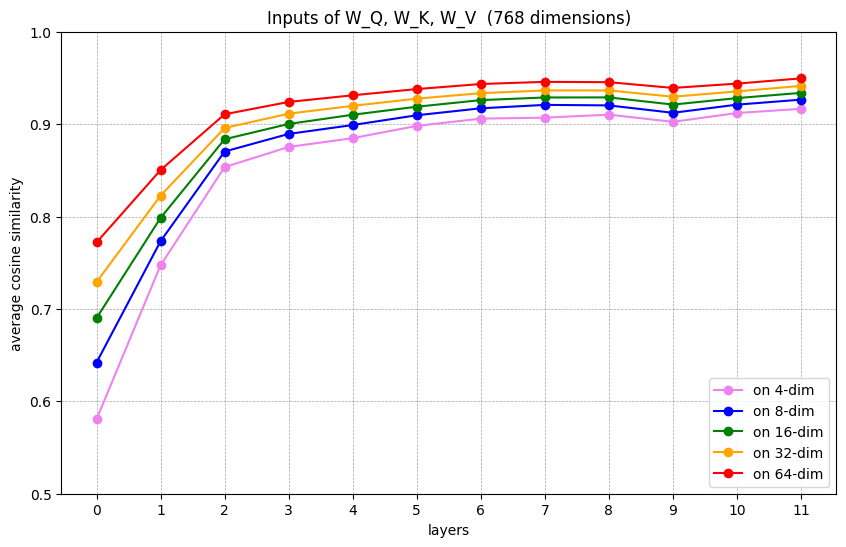

In [5]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [input_proj_length_on_4[4*l+0].item() for l in L]
v_8 = [input_proj_length_on_8[4*l+0].item() for l in L]
v_16 = [input_proj_length_on_16[4*l+0].item() for l in L]
v_32 = [input_proj_length_on_32[4*l+0].item() for l in L]
v_64 = [input_proj_length_on_64[4*l+0].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.5, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Inputs of W_Q, W_K, W_V  (768 dimensions)")
plt.legend()

plt.savefig("256_input_0.png", dpi=300, bbox_inches='tight')
plt.show()



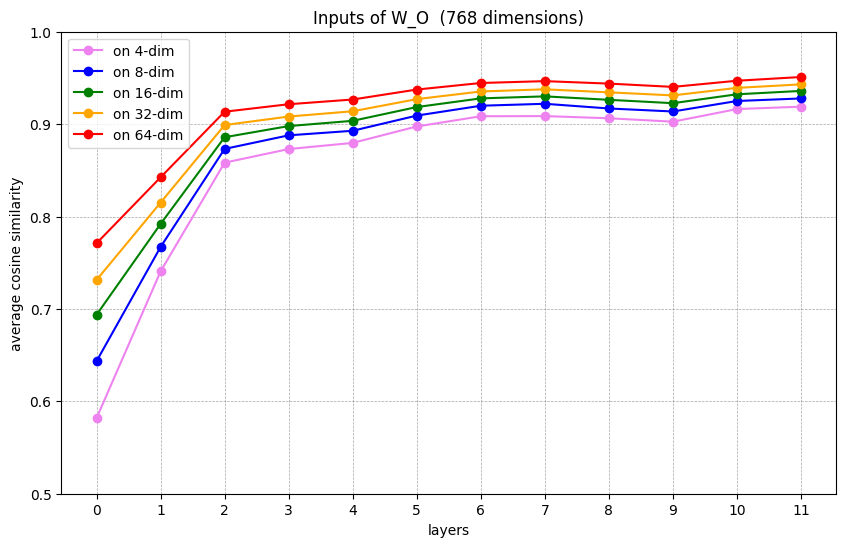

In [6]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [input_proj_length_on_4[4*l+1].item() for l in L]
v_8 = [input_proj_length_on_8[4*l+1].item() for l in L]
v_16 = [input_proj_length_on_16[4*l+1].item() for l in L]
v_32 = [input_proj_length_on_32[4*l+1].item() for l in L]
v_64 = [input_proj_length_on_64[4*l+1].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.5, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Inputs of W_O  (768 dimensions)")
plt.legend()

plt.savefig("256_input_1.png", dpi=300, bbox_inches='tight')
plt.show()



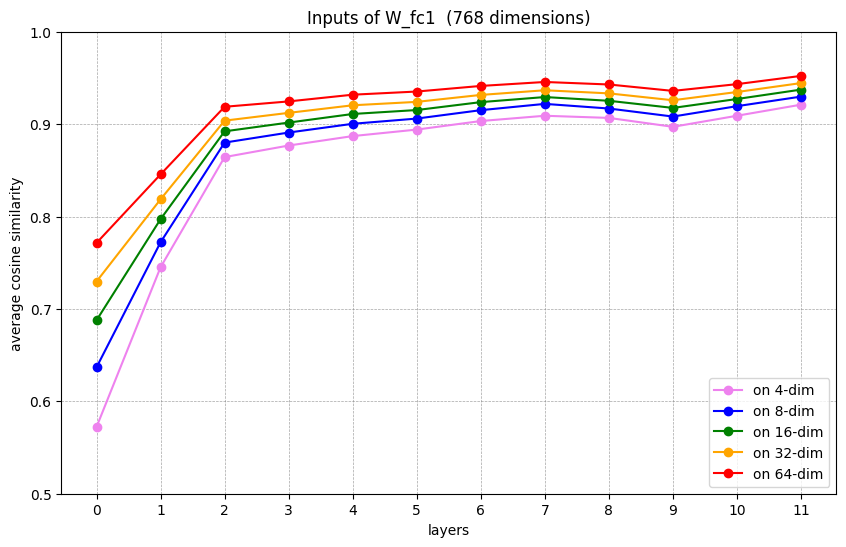

In [7]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [input_proj_length_on_4[4*l+2].item() for l in L]
v_8 = [input_proj_length_on_8[4*l+2].item() for l in L]
v_16 = [input_proj_length_on_16[4*l+2].item() for l in L]
v_32 = [input_proj_length_on_32[4*l+2].item() for l in L]
v_64 = [input_proj_length_on_64[4*l+2].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.5, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Inputs of W_fc1  (768 dimensions)")
plt.legend()

plt.savefig("256_input_2.png", dpi=300, bbox_inches='tight')
plt.show()



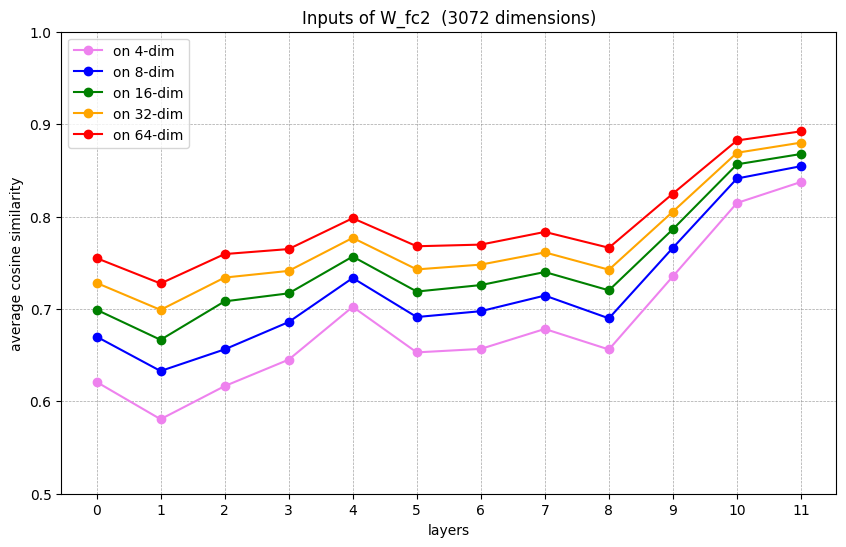

In [8]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [input_proj_length_on_4[4*l+3].item() for l in L]
v_8 = [input_proj_length_on_8[4*l+3].item() for l in L]
v_16 = [input_proj_length_on_16[4*l+3].item() for l in L]
v_32 = [input_proj_length_on_32[4*l+3].item() for l in L]
v_64 = [input_proj_length_on_64[4*l+3].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.5, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Inputs of W_fc2  (3072 dimensions)")
plt.legend()

plt.savefig("256_input_3.png", dpi=300, bbox_inches='tight')
plt.show()



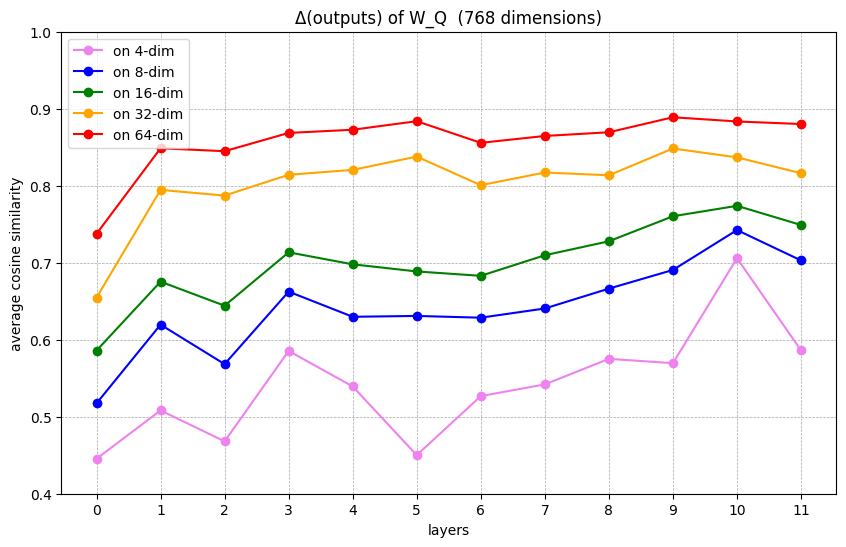

In [9]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [output_proj_length_on_4[6*l+0].item() for l in L]
v_8 = [output_proj_length_on_8[6*l+0].item() for l in L]
v_16 = [output_proj_length_on_16[6*l+0].item() for l in L]
v_32 = [output_proj_length_on_32[6*l+0].item() for l in L]
v_64 = [output_proj_length_on_64[6*l+0].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.4, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Δ(outputs) of W_Q  (768 dimensions)")
plt.legend()

plt.savefig("256_output_0.png", dpi=300, bbox_inches='tight')
plt.show()



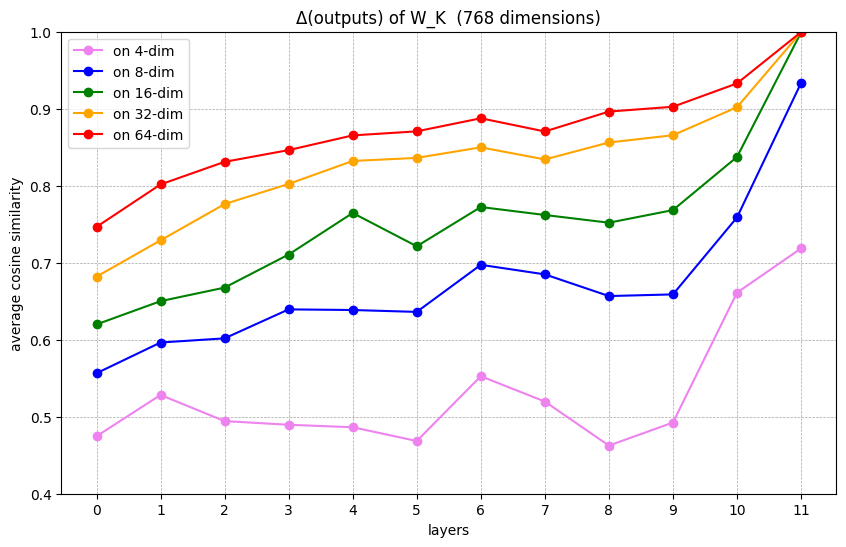

In [10]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [output_proj_length_on_4[6*l+1].item() for l in L]
v_8 = [output_proj_length_on_8[6*l+1].item() for l in L]
v_16 = [output_proj_length_on_16[6*l+1].item() for l in L]
v_32 = [output_proj_length_on_32[6*l+1].item() for l in L]
v_64 = [output_proj_length_on_64[6*l+1].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.4, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Δ(outputs) of W_K  (768 dimensions)")
plt.legend()

plt.savefig("256_output_1.png", dpi=300, bbox_inches='tight')
plt.show()



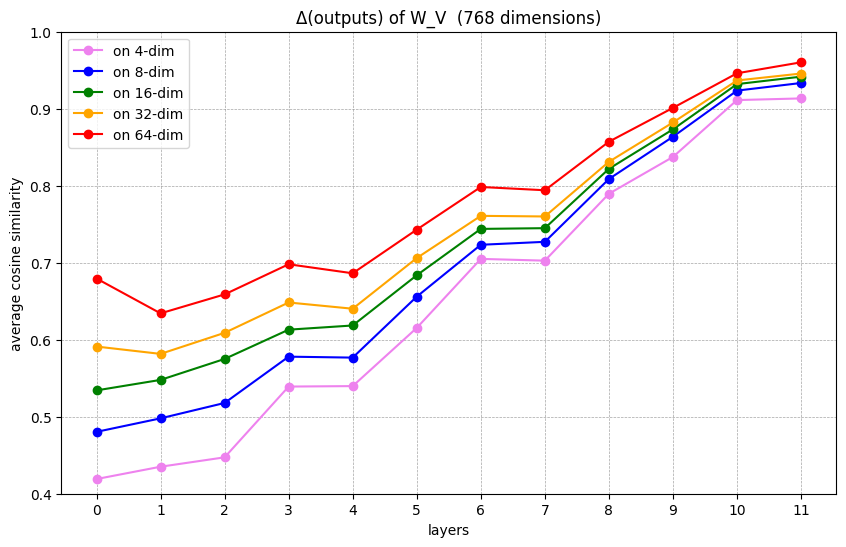

In [11]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [output_proj_length_on_4[6*l+2].item() for l in L]
v_8 = [output_proj_length_on_8[6*l+2].item() for l in L]
v_16 = [output_proj_length_on_16[6*l+2].item() for l in L]
v_32 = [output_proj_length_on_32[6*l+2].item() for l in L]
v_64 = [output_proj_length_on_64[6*l+2].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.4, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Δ(outputs) of W_V  (768 dimensions)")
plt.legend()

plt.savefig("256_output_2.png", dpi=300, bbox_inches='tight')
plt.show()



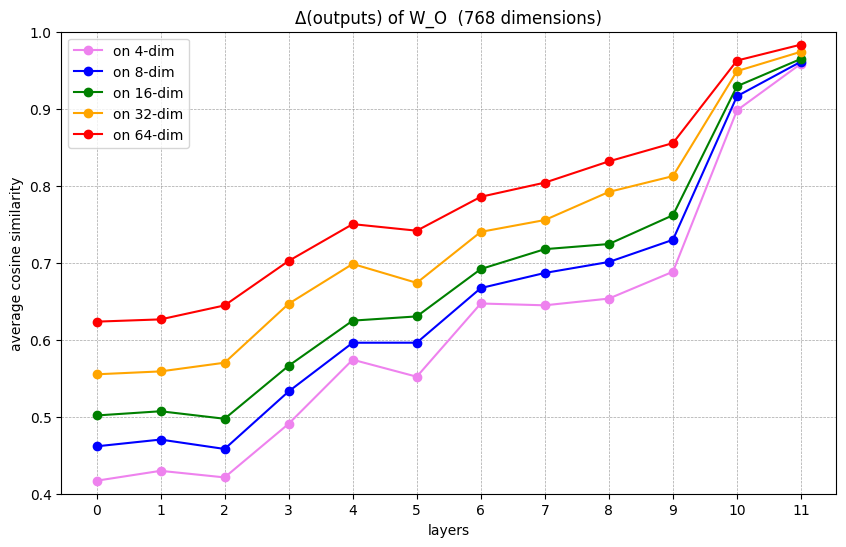

In [12]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [output_proj_length_on_4[6*l+3].item() for l in L]
v_8 = [output_proj_length_on_8[6*l+3].item() for l in L]
v_16 = [output_proj_length_on_16[6*l+3].item() for l in L]
v_32 = [output_proj_length_on_32[6*l+3].item() for l in L]
v_64 = [output_proj_length_on_64[6*l+3].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.4, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Δ(outputs) of W_O  (768 dimensions)")
plt.legend()

plt.savefig("256_output_3.png", dpi=300, bbox_inches='tight')
plt.show()



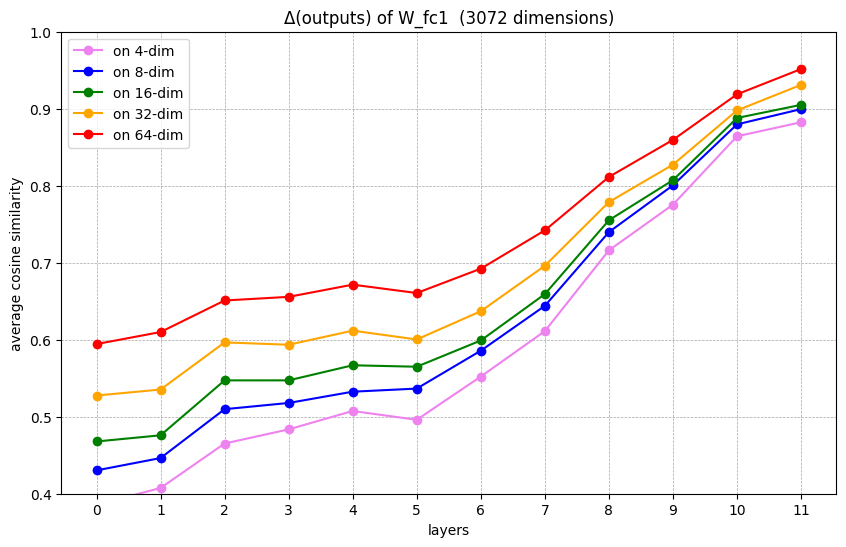

In [13]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [output_proj_length_on_4[6*l+4].item() for l in L]
v_8 = [output_proj_length_on_8[6*l+4].item() for l in L]
v_16 = [output_proj_length_on_16[6*l+4].item() for l in L]
v_32 = [output_proj_length_on_32[6*l+4].item() for l in L]
v_64 = [output_proj_length_on_64[6*l+4].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.4, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Δ(outputs) of W_fc1  (3072 dimensions)")
plt.legend()

plt.savefig("256_output_4.png", dpi=300, bbox_inches='tight')
plt.show()



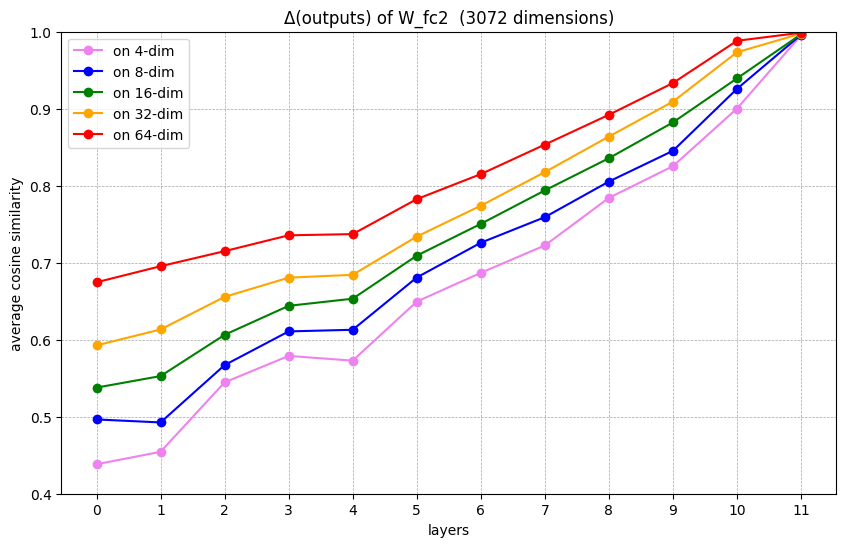

In [14]:
import matplotlib.pyplot as plt

L = list(range(12))
v_4 = [output_proj_length_on_4[6*l+5].item() for l in L]
v_8 = [output_proj_length_on_8[6*l+5].item() for l in L]
v_16 = [output_proj_length_on_16[6*l+5].item() for l in L]
v_32 = [output_proj_length_on_32[6*l+5].item() for l in L]
v_64 = [output_proj_length_on_64[6*l+5].item() for l in L]
plt.figure(figsize=(10, 6))
plt.plot(L, v_4, label="on 4-dim", marker='o', linestyle='-', color='violet')
plt.plot(L, v_8, label="on 8-dim", marker='o', linestyle='-', color='blue')
plt.plot(L, v_16, label="on 16-dim", marker='o', linestyle='-', color='green')
plt.plot(L, v_32, label="on 32-dim", marker='o', linestyle='-', color='orange')
plt.plot(L, v_64, label="on 64-dim", marker='o', linestyle='-', color='red')
plt.ylim(0.4, 1.0)
plt.xticks(ticks=range(0, 12), labels=range(0, 12))
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel("layers")
plt.ylabel("average cosine similarity")
plt.title("Δ(outputs) of W_fc2  (3072 dimensions)")
plt.legend()

plt.savefig("256_output_5.png", dpi=300, bbox_inches='tight')
plt.show()

